In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


import sys
sys.path.append("..") 
from utility import MLP, DataGenerator, rmse, l2_error, plot_output, masked_rmse, masked_mse

# CUDA support 
if torch.cuda.is_available():
    device = torch.device('cuda:5')
else:
    device = torch.device('cpu')
    
print(device)

cuda:5


In [2]:
folder_path = '/raid/sepideh/Project_MCL/1D-AEMpy-UW-metabolism-BM'
file_path = os.path.join(folder_path, "all_data_lake_modeling_mixed.csv")

df = pd.read_csv(file_path)

time = df['datetime']
df = df.drop(columns=['datetime'])

# create new variables
df['doc_diff04'] = df['docr_diff04'] + df['docl_diff04']
df['poc_diff04'] = df['pocr_diff04'] + df['pocl_diff04']

df

,depth,do_ax01,do_bc02,do_conv05,do_diff04,do_final06,do_initial00,do_pd03,doc_final06,docl_bc02,...,do_obs,doc_obs,phyco_obs,fdom_obs,poc_obs,secchi_obs,temp_obs,scaled_chla_obs,doc_diff04,poc_diff04
0,0.0,2.223120e+08,2.230776e+08,2.267030e+08,2.227493e+08,11.377818,2.311300e+08,2.227493e+08,5.943507,1.998307e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.339333,NaN,1.200372e+08,1.890041e+07
1,1.0,2.199650e+08,2.204061e+08,2.157519e+08,2.106391e+08,11.377818,2.199650e+08,2.201040e+08,5.943492,1.899623e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.388167,NaN,1.134381e+08,1.907969e+07
2,2.0,2.097000e+08,2.099567e+08,2.048007e+08,2.049932e+08,11.377818,2.097000e+08,2.096759e+08,5.943475,1.801990e+07,...,9.964167,NaN,371.531667,NaN,NaN,NaN,12.317833,NaN,1.069136e+08,1.806508e+07
3,3.0,2.056250e+08,2.057773e+08,1.991118e+08,2.025911e+08,11.377818,2.056250e+08,2.055109e+08,5.943465,1.751207e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.340500,NaN,1.031977e+08,1.750926e+07
4,4.0,2.014500e+08,2.015404e+08,1.990979e+08,1.990979e+08,11.711639,2.014500e+08,2.012874e+08,5.854266,1.700743e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.329833,NaN,9.952847e+07,1.699345e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190011,45.0,1.366915e+07,1.366915e+07,1.365258e+07,1.365258e+07,10.707904,1.366915e+07,1.365336e+07,5.108676,7.251384e+05,...,NaN,NaN,-0.029667,7.682,NaN,NaN,NaN,NaN,6.513562e+06,2.247473e+06
2190012,46.0,8.411592e+06,8.411592e+06,8.397004e+06,8.397004e+06,10.496256,8.411592e+06,8.398730e+06,5.109180,4.550910e+05,...,NaN,NaN,-0.029667,7.682,NaN,NaN,NaN,NaN,4.087344e+06,1.903929e+06
2190013,47.0,4.164276e+06,4.164276e+06,4.149462e+06,4.149462e+06,9.763440,4.164276e+06,4.154155e+06,5.112797,2.421641e+05,...,NaN,NaN,-0.029667,7.682,NaN,NaN,NaN,NaN,2.172939e+06,1.570426e+06
2190014,48.0,2.252801e+05,2.252801e+05,2.184360e+05,2.184360e+05,4.368719,2.252801e+05,2.183402e+05,5.145544,2.893348e+04,...,NaN,NaN,-0.029667,7.682,NaN,NaN,NaN,NaN,2.572772e+05,1.256602e+06


### Split data train-val-test


In [3]:

training_frac = 0.60
val_frac = 0.2

depth_steps = 50
number_days = len(df)//depth_steps

# Calculate number of observations for each set
n_obs_train = int(number_days * training_frac) * depth_steps
n_obs_val = int(number_days * val_frac) * depth_steps

print(f"Number of days total: {number_days}")

train_df = df.iloc[:n_obs_train]
val_df = df.iloc[n_obs_train:n_obs_train + n_obs_val]
test_df = df.iloc[n_obs_train + n_obs_val:]

train_time = time[:n_obs_train]
val_time = time[n_obs_train:n_obs_train + n_obs_val]
test_time = time[n_obs_train + n_obs_val:]

print(f"Number of training points: {train_df.shape}")
print(f"Number of validation points: {val_df.shape}")
print(f"Number of test points: {test_df.shape}")

Number of days total: 43800
Number of training points: (1314000, 68)
Number of validation points: (438000, 68)
Number of test points: (438016, 68)


In [4]:
train_df

,depth,do_ax01,do_bc02,do_conv05,do_diff04,do_final06,do_initial00,do_pd03,doc_final06,docl_bc02,...,do_obs,doc_obs,phyco_obs,fdom_obs,poc_obs,secchi_obs,temp_obs,scaled_chla_obs,doc_diff04,poc_diff04
0,0.0,2.223120e+08,2.230776e+08,2.267030e+08,2.227493e+08,11.377818,2.311300e+08,2.227493e+08,5.943507,1.998307e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.339333,NaN,1.200372e+08,1.890041e+07
1,1.0,2.199650e+08,2.204061e+08,2.157519e+08,2.106391e+08,11.377818,2.199650e+08,2.201040e+08,5.943492,1.899623e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.388167,NaN,1.134381e+08,1.907969e+07
2,2.0,2.097000e+08,2.099567e+08,2.048007e+08,2.049932e+08,11.377818,2.097000e+08,2.096759e+08,5.943475,1.801990e+07,...,9.964167,NaN,371.531667,NaN,NaN,NaN,12.317833,NaN,1.069136e+08,1.806508e+07
3,3.0,2.056250e+08,2.057773e+08,1.991118e+08,2.025911e+08,11.377818,2.056250e+08,2.055109e+08,5.943465,1.751207e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.340500,NaN,1.031977e+08,1.750926e+07
4,4.0,2.014500e+08,2.015404e+08,1.990979e+08,1.990979e+08,11.711639,2.014500e+08,2.012874e+08,5.854266,1.700743e+07,...,NaN,NaN,371.531667,NaN,NaN,NaN,12.329833,NaN,9.952847e+07,1.699345e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,45.0,1.278520e+07,1.278520e+07,1.275729e+07,1.275729e+07,10.005715,1.278520e+07,1.277035e+07,5.115281,6.306292e+05,...,NaN,NaN,0.149000,10.1375,NaN,NaN,NaN,NaN,6.521983e+06,2.163229e+06
1313996,46.0,7.404354e+06,7.404354e+06,7.379375e+06,7.379375e+06,9.224219,7.404354e+06,7.391995e+06,5.122676,3.989957e+05,...,NaN,NaN,0.149000,10.1375,NaN,NaN,NaN,NaN,4.098141e+06,1.893752e+06
1313997,47.0,3.178492e+06,3.178492e+06,3.155743e+06,3.155743e+06,7.425278,3.178492e+06,3.168639e+06,5.143668,2.169789e+05,...,NaN,NaN,0.149000,10.1375,NaN,NaN,NaN,NaN,2.186059e+06,1.623183e+06
1313998,48.0,1.172362e+05,1.172362e+05,1.120954e+05,1.120954e+05,2.241908,1.172362e+05,1.108733e+05,5.214820,2.755004e+04,...,NaN,NaN,0.149000,10.1375,NaN,NaN,NaN,NaN,2.607410e+05,1.361969e+06


# Normalizing Data

In [5]:
# Specify input and output columns

input_binary = ['ice_final06'] # remain unchanged

features_to_normalize = list(set(df.columns) - set(input_binary))

In [6]:
train_features_to_normalize = train_df[features_to_normalize].values
val_data_features_to_normalize = val_df[features_to_normalize].values
test_features_to_normalize = test_df[features_to_normalize].values

In [7]:
# Initialize StandardScaler and fit on training features
scaler = StandardScaler()
scaler.fit(train_features_to_normalize)

# Transform training, test, and validation features using the fitted scaler
train_df[features_to_normalize] = scaler.transform(train_features_to_normalize)
val_df[features_to_normalize] = scaler.transform(val_data_features_to_normalize)
test_df[features_to_normalize] = scaler.transform(test_features_to_normalize)

In [8]:
train_df

,depth,do_ax01,do_bc02,do_conv05,do_diff04,do_final06,do_initial00,do_pd03,doc_final06,docl_bc02,...,do_obs,doc_obs,phyco_obs,fdom_obs,poc_obs,secchi_obs,temp_obs,scaled_chla_obs,doc_diff04,poc_diff04
0,-1.697749,1.834876,1.843013,1.896808,1.839582,0.814369,1.959257,1.840076,3.139384,4.389883,...,NaN,NaN,-0.941889,NaN,NaN,NaN,-0.042863,NaN,2.735999,2.428840
1,-1.628453,1.801767,1.805363,1.742320,1.668885,0.814369,1.801752,1.802780,3.139335,4.099866,...,NaN,NaN,-0.941889,NaN,NaN,NaN,-0.036442,NaN,2.483453,2.460428
2,-1.559158,1.656958,1.658102,1.587832,1.589305,0.814369,1.656945,1.655755,3.139282,3.812939,...,0.266465,NaN,-0.941889,NaN,NaN,NaN,-0.045690,NaN,2.233765,2.281661
3,-1.489862,1.599472,1.599202,1.507579,1.555447,0.814369,1.599459,1.597034,3.139252,3.663696,...,NaN,NaN,-0.941889,NaN,NaN,NaN,-0.042710,NaN,2.091556,2.183729
4,-1.420566,1.540575,1.539492,1.507382,1.506209,0.891467,1.540562,1.537487,2.859550,3.515390,...,NaN,NaN,-0.941889,NaN,NaN,NaN,-0.044112,NaN,1.951137,2.092846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313995,1.420566,-1.120931,-1.120614,-1.121329,-1.120305,0.497473,-1.120922,-1.120394,0.542290,-1.297487,...,NaN,NaN,-2.049824,-0.993122,NaN,NaN,NaN,NaN,-1.608191,-0.520140
1313996,1.489862,-1.196839,-1.196445,-1.197195,-1.196108,0.316982,-1.196829,-1.196223,0.565480,-1.365560,...,NaN,NaN,-2.049824,-0.993122,NaN,NaN,NaN,NaN,-1.700951,-0.567621
1313997,1.559158,-1.256453,-1.256000,-1.256778,-1.255641,-0.098494,-1.256443,-1.255768,0.631306,-1.419052,...,NaN,NaN,-2.049824,-0.993122,NaN,NaN,NaN,NaN,-1.774125,-0.615293
1313998,1.628453,-1.299639,-1.299142,-1.299715,-1.298542,-1.295625,-1.299628,-1.298879,0.854419,-1.474722,...,NaN,NaN,-2.049824,-0.993122,NaN,NaN,NaN,NaN,-1.847807,-0.661317


In [9]:
#keeping track of the mean and standard deviations
train_mean = scaler.mean_
train_std = scaler.scale_

# Get index of the binary column
ice_ix = df.columns.get_loc("ice_final06")

# Insert placeholder mean/std at the correct index
train_mean_full = np.insert(scaler.mean_, ice_ix, 0.0)  # mean for binary is 0
train_std_full = np.insert(scaler.scale_, ice_ix, 1.0)  # std for binary is 1 (no scaling)

train_mean = train_mean_full
train_std = train_std_full

# Loading Models

In [10]:
# m1: Input and Output
m1_input_columns = ['depth', 
                    'day_of_year_list', 'time_of_day_list', # time features
                    'temp_initial00', 'do_initial00', # 2D var
                    'area_input', 'volume_input', # depth specific var
                    'Air_Temperature_celsius', 'Ten_Meter_Elevation_Wind_Speed_meterPerSecond', # Meteorological var, time specific var
                    'ice_final06']
m1_output_columns = ['do_ax01']

# Get index positions for columns
m1_input_column_ix = [df.columns.get_loc(col) for col in m1_input_columns]
m1_output_column_ix = [df.columns.get_loc(col) for col in m1_output_columns]


# Exclude the inputs which are output of previous model
# pass

# Model config
m1_PATH = f"../saved_models/pretrain/m1.pth"
m1_layers = [len(m1_input_columns), 32, 32, len(m1_output_columns)]

# Load model
m1_model = MLP(m1_layers, activation="gelu")
m1_checkpoint = torch.load(m1_PATH, map_location=torch.device('cpu'))
m1_model.load_state_dict(m1_checkpoint)
m1_model = m1_model.to(device)

# --------------------------------------------------------------------------
# m2: Input and Output
m2_input_columns = ['depth', 
                    'day_of_year_list', 'time_of_day_list', # time features
                    'temp_initial00', 'do_ax01', 'docr_initial00', 'docl_initial00', 'pocr_initial00', 'pocl_initial00',
                    'area_input', 'volume_input', 'ice_final06',
                    'Air_Temperature_celsius', 'Cloud_Cover', 'ea', 'Shortwave_Radiation_Downwelling_wattPerMeterSquared' , 'Longwave_Radiation_Downwelling_wattPerMeterSquared',
                    'tp_initial']
m2_output_columns = ['do_bc02', 'docr_bc02', 'docl_bc02', 'pocr_bc02', 'pocl_bc02', 'npp_bc02']

# Get index positions for columns
m2_input_column_ix = [df.columns.get_loc(col) for col in m2_input_columns]
m2_output_column_ix = [df.columns.get_loc(col) for col in m2_output_columns]

# Exclude the inputs which are output of previous model
m2_input_iso_ix = [ix for ix in m2_input_column_ix if ix not in m1_output_column_ix]

# Model config
m2_PATH = f"../saved_models/pretrain/m2.pth"
m2_layers = [len(m2_input_columns), 32, 32, len(m2_output_columns)]

# Load model
m2_model = MLP(m2_layers, activation="gelu")
m2_checkpoint = torch.load(m2_PATH, map_location=torch.device('cpu'))
m2_model.load_state_dict(m2_checkpoint)
m2_model = m2_model.to(device)

# --------------------------------------------------------------------------
# m3: Input and Output
m3_input_columns = ['depth', 
                    'day_of_year_list', 'time_of_day_list', # time features
                    
                    'temp_initial00', 'do_bc02', 'docl_bc02', 'docr_bc02', 'pocl_bc02', 'pocr_bc02', 
                    'area_input', 'volume_input',]
m3_output_columns = ['do_pd03', 'docr_pd03','docl_pd03','pocr_pd03','pocl_pd03', 'docr_resp_pd03', 'docl_resp_pd03','poc_resp_pd03']

# Get index positions for columns
m3_input_column_ix = [df.columns.get_loc(col) for col in m3_input_columns]
m3_output_column_ix = [df.columns.get_loc(col) for col in m3_output_columns]


# Exclude the inputs which are output of previous model
m3_input_iso_ix = [ix for ix in m3_input_column_ix if ix not in m2_output_column_ix]


# Model config
m3_PATH = f"../saved_models/pretrain/m3.pth"
m3_layers = [len(m3_input_columns), 32, 32, len(m3_output_columns)]

# Load model
m3_model = MLP(m3_layers, activation="gelu")
m3_checkpoint = torch.load(m3_PATH, map_location=torch.device('cpu'))
m3_model.load_state_dict(m3_checkpoint)
m3_model = m3_model.to(device)

# --------------------------------------------------------------------------
# m4: Input and Output
m4_input_columns = ['depth', 
                    'day_of_year_list', 'time_of_day_list', # time features
                    
                    # inputs
                    'temp_initial00', 'do_pd03', 'docl_pd03', 'docr_pd03', 'pocl_pd03', 'pocr_pd03', 'kz_initial00', 
                    'Ten_Meter_Elevation_Wind_Speed_meterPerSecond', 
                    'area_input', 'volume_input',]
m4_output_columns = ['do_diff04', 'poc_diff04', 'doc_diff04']

# Get index positions for columns
m4_input_column_ix = [df.columns.get_loc(col) for col in m4_input_columns]
m4_output_column_ix = [df.columns.get_loc(col) for col in m4_output_columns]


# Exclude the inputs which are output of previous model
m4_input_iso_ix = [ix for ix in m4_input_column_ix if ix not in m3_output_column_ix]

# Model config
m4_PATH = f"../saved_models/pretrain/m4.pth"
m4_layers = [len(m4_input_columns), 32, 32, len(m4_output_columns)]

# Load model
m4_model = MLP(m4_layers, activation="gelu")
m4_checkpoint = torch.load(m4_PATH, map_location=torch.device('cpu'))
m4_model.load_state_dict(m4_checkpoint)
m4_model = m4_model.to(device)


Initializing Network with Xavier Initialization..
Initializing Network with Xavier Initialization..
Initializing Network with Xavier Initialization..
Initializing Network with Xavier Initialization..


In [11]:
# define obs columns
obs_columns = ['do_obs', 'poc_obs','doc_obs']

obs_columns_ix = [df.columns.get_loc(column) for column in obs_columns]

obs_to_model_map = {
    'do_obs': 'do_diff04',
    'doc_obs': 'doc_diff04',
    'poc_obs': 'poc_diff04'
}


# Data Loader

In [12]:
train_array = train_df.values
test_array = test_df.values
val_array = val_df.values

# Create data set
batch_size = 1024
train_dataset = DataGenerator(train_df)
val_dataset = DataGenerator(val_df)
test_dataset = DataGenerator(test_df)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)
print(train_df.shape)
print(val_df.shape)

(1314000, 68)
(438000, 68)


In [13]:
def get_rollout_predictions(m1_model, m2_model, m3_model, m4_model, loader, plot = True):    
    m1_model.eval()
    m2_model.eval()
    m3_model.eval()
    m4_model.eval()

    y_ = []
    y_obs_ = []
    pred_ = []
    
    # Use simulation statistics for normalizing observed data
    sim_mean = torch.tensor(train_mean[m4_output_column_ix]).float().to(device)
    sim_std = torch.tensor(train_std[m4_output_column_ix]).float().to(device)

    obs_mean = torch.tensor(train_mean[obs_columns_ix]).float().to(device)
    obs_std = torch.tensor(train_std[obs_columns_ix]).float().to(device)

    rmse_models = np.zeros((len(loader), 5))
    for ix, x in enumerate(iter(loader)):
        x = x.to(device).float()
        
        m1_input = x[:, m1_input_column_ix]
            
        #model 1
        m1_pred = m1_model(m1_input)
        # breakpoint()
        if plot:
            m1_y_true = x[:, m1_output_column_ix[0]] * torch.tensor(train_std[m1_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m1_output_column_ix[0]]).to(device)
            m1_y_pred = m1_pred * torch.tensor(train_std[m1_output_column_ix[0]]).to(device) + torch.tensor(train_mean[m1_output_column_ix[0]]).to(device)
            rmse_models[ix, 0] = rmse(m1_y_true.squeeze(), m1_y_pred.squeeze())
            print("RMSE of after m1", rmse(m1_y_true.flatten(), m1_y_pred.flatten()))

        #model 2
        m2_input = torch.cat([x[:, m2_input_iso_ix], m1_pred], dim=-1)
        m2_pred = m2_model(m2_input)
        # breakpoint()
        if plot:
            m2_y_true = x[:, m2_output_column_ix] * torch.tensor(train_std[m2_output_column_ix]).to(device) + torch.tensor(train_mean[m2_output_column_ix]).to(device)
            m2_y_pred = m2_pred * torch.tensor(train_std[m2_output_column_ix]).to(device) + torch.tensor(train_mean[m2_output_column_ix]).to(device)
            rmse_models[ix, 1] = rmse(m2_y_true.squeeze(), m2_y_pred.squeeze())
            print("RMSE of after m2", rmse(m2_y_true.flatten(), m2_y_pred.flatten()))

        #model 3
        m2_output_shared_ix = [ix for ix in m2_output_column_ix if ix in m3_input_column_ix]
        relative_shared_ix = [m2_output_column_ix.index(ix) for ix in m2_output_shared_ix]
        m2_pred_selected = m2_pred[:, relative_shared_ix]
        m3_input = torch.cat([x[:, m3_input_iso_ix], m2_pred_selected], dim=-1)
        m3_pred = m3_model(m3_input)
        # breakpoint()    
        if plot:
            m3_y_true = x[:, m3_output_column_ix] * torch.tensor(train_std[m3_output_column_ix]).to(device) + torch.tensor(train_mean[m3_output_column_ix]).to(device)
            m3_y_pred = m3_pred * torch.tensor(train_std[m3_output_column_ix]).to(device) + torch.tensor(train_mean[m3_output_column_ix]).to(device)
            rmse_models[ix, 3] = rmse(m3_y_true.squeeze(), m3_y_pred.squeeze())
            print("RMSE of after m3", rmse(m3_y_true.flatten(), m3_y_pred.flatten()))

        # breakpoint()
            
        #model 4
        m3_output_shared_ix = [ix for ix in m3_output_column_ix if ix in m4_input_column_ix]
        relative_shared_ix = [m3_output_column_ix.index(ix) for ix in m3_output_shared_ix]
        m3_pred_selected = m3_pred[:, relative_shared_ix]
        m4_input = torch.cat([x[:, m4_input_iso_ix], m3_pred_selected], dim=-1)
        m4_pred = m4_model(m4_input)
        # breakpoint()

        mean = torch.tensor(train_mean[m4_output_column_ix]).to(device)
        std = torch.tensor(train_std[m4_output_column_ix]).to(device)

        obs_mean = torch.tensor(train_mean[obs_columns_ix]).float().to(device)
        obs_std = torch.tensor(train_std[obs_columns_ix]).float().to(device)
        if plot:
            m4_y_true = x[:, m4_output_column_ix] * std + mean
            m4_y_pred = m4_pred * std + mean
            rmse_models[ix, 4] = rmse(m4_y_true.squeeze(), m4_y_pred.squeeze())
            print("RMSE of after m4", rmse(m4_y_true.flatten(), m4_y_pred.flatten()))
        
        # store the predictions
        y_true = x[:, m4_output_column_ix]
        y_obs = x[:, obs_columns_ix] * obs_std + obs_mean
        y_obs_norm = (y_obs - sim_mean) / sim_std
        pred = m4_pred
        
        y_.append(y_true)
        y_obs_.append(y_obs_norm)
        pred_.append(pred)

    y_ = torch.cat(y_, dim=0)
    y_obs_ = torch.cat(y_obs_, dim=0)
    pred_ = torch.cat(pred_, dim=0) 

    return pred_, y_, y_obs_, rmse_models

# RUN

In [14]:

train_y_pred, train_y_true, train_y_obs, train_rmse_models = get_rollout_predictions(m1_model, m2_model, m3_model, m4_model, train_loader, plot = True)

train_rmse = rmse(train_y_pred.flatten(), train_y_true.flatten())
train_rmse_obs = masked_rmse(train_y_pred.flatten(), train_y_obs.flatten())
train_l2 = l2_error(train_y_pred.flatten(), train_y_true.flatten())

print(f"Train RMSE Simulated: {train_rmse}")
print(f"Train RMSE Observed Temp: {train_rmse_obs}")
print(f"Train L2 Error: {train_l2}")
print(f"The RMSEs after each modelling stage: {train_rmse_models.mean(axis=0)}")

RMSE of after m1 30539.049
RMSE of after m2 16094338.404641733
RMSE of after m3 12651545.153311959
RMSE of after m4 3149007.745023617
RMSE of after m1 23953.127
RMSE of after m2 16527087.433295142
RMSE of after m3 12149472.731532542
RMSE of after m4 3161635.884796685
RMSE of after m1 23283.748
RMSE of after m2 16632558.376923349
RMSE of after m3 12353295.331924694
RMSE of after m4 3011141.8118415372
RMSE of after m1 24592.088
RMSE of after m2 16122179.52422862
RMSE of after m3 11723713.2260816
RMSE of after m4 2930534.4643972027
RMSE of after m1 28566.648
RMSE of after m2 15948796.281672582
RMSE of after m3 12389828.820116758
RMSE of after m4 3236619.9087685077
RMSE of after m1 23660.709
RMSE of after m2 16495298.11389508
RMSE of after m3 12003778.343120974
RMSE of after m4 3287992.708930016
RMSE of after m1 25799.287
RMSE of after m2 16134967.918988468
RMSE of after m3 11887080.391761536
RMSE of after m4 3042702.092886129
RMSE of after m1 26164.203
RMSE of after m2 16373241.095827214


In [15]:
# plot_output(train_y_pred[:, 2], train_y_true[:, 2], depth_steps, train_time, figsize=(20,10))


In [16]:
# plot_output(train_y_pred[:, 0], train_y_obs[:, 0], depth_steps, train_time, figsize=(20,10))

# Finetuning

In [17]:
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False

def unfreeze_model(model):
    for param in model.parameters():
        param.requires_grad = True
        
freeze_model(m1_model)
freeze_model(m2_model)
freeze_model(m3_model)
unfreeze_model(m4_model)


In [18]:
m1_model = m1_model.to(device) 
print(next(m1_model.parameters()).device)

cuda:5


In [19]:
# Ensure predicted and observed variables are matched
for model_var, obs_var in zip(m4_output_columns, obs_columns):
    assert model_var.split('_')[0] == obs_var.split('_')[0], f"Mismatch: {model_var} vs {obs_var}"

# Set models to train mode

m1_model = m1_model.to(device)
m2_model = m2_model.to(device)
m3_model = m3_model.to(device)
m4_model = m4_model.to(device)

m1_model.train()
m2_model.train()
m3_model.train()
m4_model.train()

n_epochs = 3
criterion = nn.MSELoss()
lr = 1e-5
optimizer = torch.optim.Adam(m4_model.parameters(), lr=lr,
                             betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)

# Use simulation statistics for normalizing observed data
sim_mean = torch.tensor(train_mean[m4_output_column_ix]).float().to(device)
sim_std = torch.tensor(train_std[m4_output_column_ix]).float().to(device)

obs_mean = torch.tensor(train_mean[obs_columns_ix]).float().to(device)
obs_std = torch.tensor(train_std[obs_columns_ix]).float().to(device)

train_loss = []
val_loss = []
loss_dict = {k: [] for k in ["m1", "m2", "m3", "m4"]}

for epoch in tqdm(range(n_epochs)):
    epoch_loss = 0.0
    epoch_loss_parts = {k: 0.0 for k in loss_dict}

    for batch in train_loader:
        x = batch.to(device).float()
        optimizer.zero_grad()

        # M1
        m1_input = x[:, m1_input_column_ix]
        m1_pred = m1_model(m1_input)
        loss_m1 = criterion(m1_pred, x[:, m1_output_column_ix])

        # M2
        m2_input = torch.cat([x[:, m2_input_iso_ix], m1_pred], dim=-1)
        m2_pred = m2_model(m2_input)
        loss_m2 = criterion(m2_pred, x[:, m2_output_column_ix])

        # M3
        shared_ix_2_3 = [ix for ix in m2_output_column_ix if ix in m3_input_column_ix]
        rel_ix_2 = [m2_output_column_ix.index(ix) for ix in shared_ix_2_3]
        m2_selected = m2_pred[:, rel_ix_2]

        m3_input = torch.cat([x[:, m3_input_iso_ix], m2_selected], dim=-1)
        m3_pred = m3_model(m3_input)
        loss_m3 = criterion(m3_pred, x[:, m3_output_column_ix])

        # M4
        shared_ix_3_4 = [ix for ix in m3_output_column_ix if ix in m4_input_column_ix]
        rel_ix_3 = [m3_output_column_ix.index(ix) for ix in shared_ix_3_4]
        m3_selected = m3_pred[:, rel_ix_3]

        m4_input = torch.cat([x[:, m4_input_iso_ix], m3_selected], dim=-1)
        m4_pred = m4_model(m4_input)

        # Normalize observed data using simulation stats
        obs_true = x[:, obs_columns_ix] * obs_std + obs_mean
        obs_true_norm = (obs_true - sim_mean) / sim_std
        loss_m4 = masked_mse(m4_pred, obs_true_norm)

        # Backpropagation only through M4
        loss_m4.backward()
        optimizer.step()

        # Track losses
        epoch_loss += loss_m4.item()
        epoch_loss_parts["m1"] += loss_m1.item()
        epoch_loss_parts["m2"] += loss_m2.item()
        epoch_loss_parts["m3"] += loss_m3.item()
        epoch_loss_parts["m4"] += loss_m4.item()

    # Save average losses
    train_loss.append(epoch_loss / len(train_loader))
    for k in loss_dict:
        loss_dict[k].append(epoch_loss_parts[k] / len(train_loader))

    # # ===== Validation Loss =====
    # m4_model.eval()
    # val_epoch_loss = 0.0
    # with torch.no_grad():
    #     for batch in val_loader:
    #         x = batch.to(device).float()

    #         m1_input = x[:, m1_input_column_ix]
    #         m1_pred = m1_model(m1_input)

    #         m2_input = torch.cat([x[:, m2_input_iso_ix], m1_pred], dim=-1)
    #         m2_pred = m2_model(m2_input)

    #         shared_ix_2_3 = [ix for ix in m2_output_column_ix if ix in m3_input_column_ix]
    #         rel_ix_2 = [m2_output_column_ix.index(ix) for ix in shared_ix_2_3]
    #         m2_selected = m2_pred[:, rel_ix_2]

    #         m3_input = torch.cat([x[:, m3_input_iso_ix], m2_selected], dim=-1)
    #         m3_pred = m3_model(m3_input)

    #         shared_ix_3_4 = [ix for ix in m3_output_column_ix if ix in m4_input_column_ix]
    #         rel_ix_3 = [m3_output_column_ix.index(ix) for ix in shared_ix_3_4]
    #         m3_selected = m3_pred[:, rel_ix_3]

    #         m4_input = torch.cat([x[:, m4_input_iso_ix], m3_selected], dim=-1)
    #         m4_pred = m4_model(m4_input)

    #         obs_true = x[:, obs_columns_ix] * obs_std + obs_mean
    #         obs_true_norm = (obs_true - sim_mean) / sim_std
    #         val_batch_loss = masked_rmse(m4_pred, obs_true_norm)

    #         val_epoch_loss += val_batch_loss.item()

    # val_loss.append(val_epoch_loss / len(val_loader))
    # m4_model.train()  # restore training mode
#  Val Loss = {val_loss[-1]:.4f},
    print(f"Epoch {epoch}: Train Loss = {train_loss[-1]:.4f}, " +
          ", ".join([f"{k.upper()} = {loss_dict[k][-1]:.4f}" for k in loss_dict]))



 33%|███▎      | 1/3 [02:06<04:12, 126.34s/it]

Epoch 0: Train Loss = 202.7369, M1 = 0.0000, M2 = 0.9580, M3 = 34.5322, M4 = 202.7369


 67%|██████▋   | 2/3 [04:12<02:06, 126.23s/it]

Epoch 1: Train Loss = 182.1736, M1 = 0.0000, M2 = 0.9581, M3 = 34.5387, M4 = 182.1736


100%|██████████| 3/3 [06:18<00:00, 126.15s/it]

Epoch 2: Train Loss = 163.6868, M1 = 0.0000, M2 = 0.9583, M3 = 34.5308, M4 = 163.6868


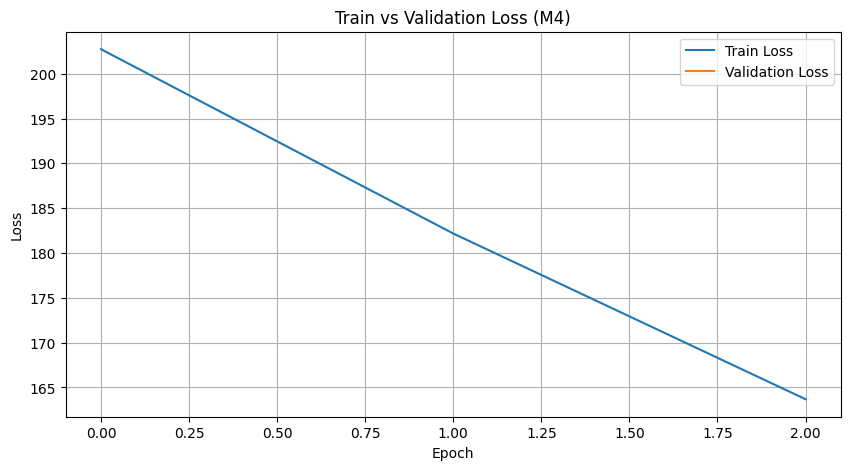

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Loss (M4)")
plt.grid(True)
plt.show()